In [ ]:
#Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("dim_customer.csv", na_values=["NULL"])

print("shape:", df.shape)
print()
print(df["is_churned"].value_counts())
print()
print(df["geography"].value_counts())
df.head()

shape: (10000, 21)

is_churned
0    7963
1    2037
Name: count, dtype: int64

geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64


,cust_key,customer_id,age,gender,tenure_months,credit_score,num_products,is_churned,churn_month,clv_ltv,...,avg_ticket_res_time_hrs,total_tickets,high_severity_tickets,offers_received,offers_accepted,offer_acceptance_rate,dw_start_date,dw_end_date,is_current,geography
0,3,15565714,47,Male,12,601,2,0,NaN,1494.73,...,NaN,2,0,4,0,0.0,2024-12-31,9999-12-31,1,France
1,6,15565806,38,Male,108,532,2,0,NaN,0.00,...,NaN,0,0,5,0,0.0,2024-12-31,9999-12-31,1,France
2,8,15565879,28,Female,108,845,2,0,NaN,0.00,...,NaN,0,0,5,0,0.0,2024-12-31,9999-12-31,1,France
3,9,15565891,39,Male,96,709,2,0,NaN,0.00,...,NaN,0,0,0,0,NaN,2024-12-31,9999-12-31,1,France
4,10,15565996,44,Male,96,653,2,0,NaN,0.00,...,NaN,0,0,5,1,0.2,2024-12-31,9999-12-31,1,France


In [ ]:
#nulls

In [2]:
df.isna().sum()[df.isna().sum() > 0]

,0
churn_month,7963
avg_ticket_res_time_hrs,8277
offer_acceptance_rate,1665


In [ ]:
#chart style

In [3]:
STAYED, CHURNED = "#3B6EA8", "#C4622D"
GRID, INK, MUTED = "#E3E6EA", "#262626", "#6B7280"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "figure.dpi": 110,
})
print("style set")

style set


In [ ]:
#churn by country

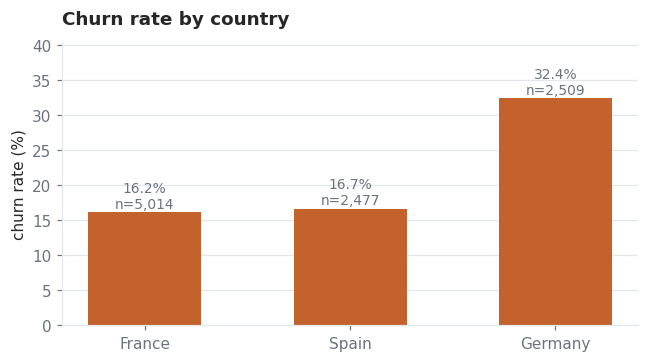

In [4]:
g = df.groupby("geography")["is_churned"].agg(["mean", "size"]).sort_values("mean")

fig, ax = plt.subplots(figsize=(6, 3.4))
bars = ax.bar(g.index, g["mean"] * 100, color=CHURNED, width=0.55)
for b, (rate, n) in zip(bars, g.values):
    ax.text(b.get_x() + b.get_width()/2, rate*100 + 0.6,
            f"{rate*100:.1f}%\nn={int(n):,}", ha="center", fontsize=9, color=MUTED)
ax.set_ylabel("churn rate (%)")
ax.set_title("Churn rate by country", fontsize=12, weight="bold", loc="left", pad=12)
ax.set_ylim(0, g["mean"].max()*100 + 8)
ax.set_axisbelow(True); ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

In [ ]:
#features

In [6]:
d = df.copy()
d["has_tickets"] = (d["total_tickets"] > 0).astype(int)

y = d["is_churned"]

X = d.drop(columns=[
    "is_churned",                                   # target
    "churn_month",                                  # LEAKS THE ANSWER
    "cust_key", "customer_id",                      # identifiers
    "dw_start_date", "dw_end_date", "is_current",   # SCD-2 bookkeeping
])

X = pd.get_dummies(X, columns=["gender", "geography"], drop_first=True)
X = X.fillna(0)

print("X:", X.shape, " y:", y.shape)
print()
print(list(X.columns))

X: (10000, 16)  y: (10000,)

['age', 'tenure_months', 'credit_score', 'num_products', 'clv_ltv', 'avg_monthly_balance', 'avg_ticket_res_time_hrs', 'total_tickets', 'high_severity_tickets', 'offers_received', 'offers_accepted', 'offer_acceptance_rate', 'has_tickets', 'gender_Male', 'geography_Germany', 'geography_Spain']


In [ ]:
#Split

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"train {X_train.shape[0]:,}   churn rate {y_train.mean():.3f}")
print(f"test  {X_test.shape[0]:,}   churn rate {y_test.mean():.3f}")

train 8,000   churn rate 0.204
test  2,000   churn rate 0.203


In [ ]:
#Train

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

scaler = StandardScaler().fit(X_train)
logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(scaler.transform(X_train), y_train)

rf = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

print("both trained")

both trained


In [ ]:
#Evaluation

In [18]:
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, roc_curve)

proba_lr = logreg.predict_proba(scaler.transform(X_test))[:, 1]
proba_rf = rf.predict_proba(X_test)[:, 1]
pred_rf  = rf.predict(X_test)

print(f"logistic regression   ROC AUC = {roc_auc_score(y_test, proba_lr):.4f}")
print(f"random forest         ROC AUC = {roc_auc_score(y_test, proba_rf):.4f}")
print()
print("random forest, default 0.5 threshold:")
print(classification_report(y_test, pred_rf, target_names=["stayed", "churned"]))

logistic regression   ROC AUC = 0.7603
random forest         ROC AUC = 0.7997

random forest, default 0.5 threshold:
              precision    recall  f1-score   support

      stayed       0.89      0.88      0.88      1593
     churned       0.54      0.56      0.55       407

    accuracy                           0.81      2000
   macro avg       0.71      0.72      0.71      2000
weighted avg       0.81      0.81      0.81      2000



In [ ]:
#Confusion matrix

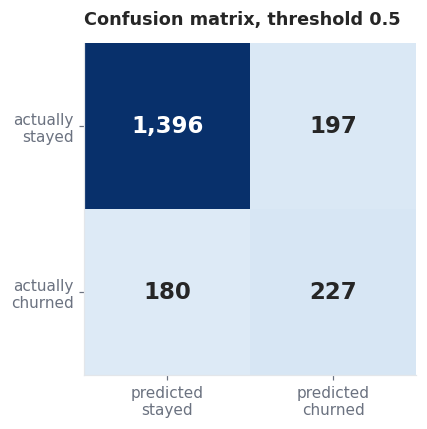

caught 227 of 407 churners (56%)


In [10]:
cm = confusion_matrix(y_test, pred_rf)

fig, ax = plt.subplots(figsize=(4.6, 4))
ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=15,
                weight="bold", color="white" if cm[i, j] > cm.max()*0.5 else INK)
ax.set_xticks([0, 1], ["predicted\nstayed", "predicted\nchurned"])
ax.set_yticks([0, 1], ["actually\nstayed", "actually\nchurned"])
ax.set_title("Confusion matrix, threshold 0.5", fontsize=11.5, weight="bold",
             loc="left", pad=12)
ax.grid(False)
plt.tight_layout(); plt.show()

print(f"caught {cm[1,1]} of {cm[1,0]+cm[1,1]} churners "
      f"({cm[1,1]/(cm[1,0]+cm[1,1]):.0%})")

In [ ]:
#feature importance

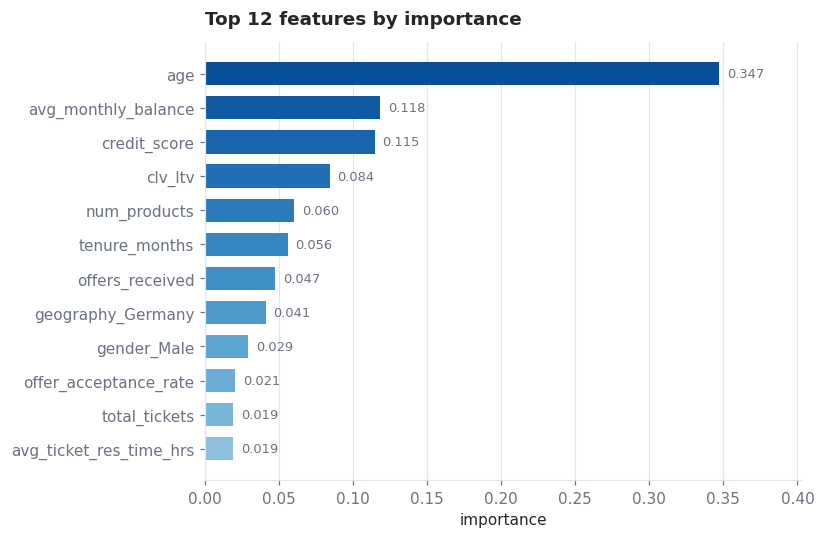

age                        0.347172
avg_monthly_balance        0.118315
credit_score               0.114555
clv_ltv                    0.084218
num_products               0.060059
tenure_months              0.055720
offers_received            0.047331
geography_Germany          0.040997
gender_Male                0.029049
offer_acceptance_rate      0.020513
total_tickets              0.018832
avg_ticket_res_time_hrs    0.018824


In [15]:
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
top = imp.tail(12)
shades = plt.cm.Blues(np.linspace(0.42, 0.88, len(top)))

fig, ax = plt.subplots(figsize=(7.6, 5))
ax.barh(top.index, top.values, color=shades, height=0.68)
for i, v in enumerate(top.values):
    ax.text(v + top.max()*0.015, i, f"{v:.3f}", va="center",
            fontsize=8.5, color=MUTED)
ax.set_xlabel("importance"); ax.set_xlim(0, top.max()*1.16)
ax.set_title("Top 12 features by importance", fontsize=12, weight="bold",
             loc="left", pad=12)
ax.grid(axis="y", visible=False); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

print(imp.sort_values(ascending=False).head(12).to_string())

In [ ]:
#export

In [16]:
out = df.loc[X_test.index, ["customer_id", "geography", "age",
                            "tenure_months", "avg_monthly_balance"]].copy()
out["actual_churn"] = y_test.values
out["churn_risk"]   = proba_rf.round(4)
out["flagged"]      = tuned
out = out.sort_values("churn_risk", ascending=False)

out.to_csv("churn_predictions.csv", index=False)
imp.sort_values(ascending=False).to_csv("feature_importance.csv", header=["importance"])

print("top 10 highest-risk customers:")
out.head(10)

top 10 highest-risk customers:


,customer_id,geography,age,tenure_months,avg_monthly_balance,actual_churn,churn_risk,flagged
6553,15719508,Germany,49,84,117435.415000,1,0.9322,1
7137,15778154,Germany,50,48,122781.570000,1,0.9219,1
5253,15588090,Germany,51,96,106291.636875,1,0.9078,1
7448,15808674,Germany,45,72,127022.755714,1,0.9017,1
5978,15659931,Germany,55,12,123672.604375,1,0.9005,1
7935,15608338,Spain,55,108,118864.040588,1,0.8819,1
5090,15571869,Germany,50,48,114458.881429,1,0.8796,1
5460,15608381,Germany,50,24,122963.487222,1,0.8777,1
6323,15694765,Germany,49,72,115986.009286,1,0.8767,1
6993,15766044,Germany,49,48,123684.998421,1,0.8754,1


In [ ]:
#Download

In [17]:
from google.colab import files
files.download("churn_predictions.csv")
files.download("feature_importance.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>